In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("../data/output/final_star.csv")

/tmp/ipykernel_768755/2738999149.py:1: DtypeWarning: Columns (100,101,102,103,104,105,106,107,108,111) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/output/final_star.csv")


In [3]:
print(list(data.columns))

['contractid', 'planid', 'fips', 'year', 'n_nonmiss', 'avg_enrollment', 'sd_enrollment', 'min_enrollment', 'max_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'egbp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'sd_eligibles', 'min_eligibles', 'max_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_reb', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'avg_ffscost', 'parta_enroll', 'partb_enroll', 'metric_01', 'metric_02', 'metric_03', 'metric_04'

### Question 1

In [4]:
# Question 1: 

d1 = data.copy()

# choose and clean variables
d1["star_rating"] = pd.to_numeric(d1["partcd_score"], errors="coerce")  # overall star rating proxy
d1["enrollment"] = pd.to_numeric(d1["avg_enrollment"], errors="coerce")
d1["market_share"] = np.where(
    pd.to_numeric(d1["avg_enrolled"], errors="coerce") > 0,
    d1["enrollment"] / pd.to_numeric(d1["avg_enrolled"], errors="coerce"),
    np.nan
)

# create table
summary = (
    d1.loc[d1["year"].between(2010, 2015)]
      .groupby("year")
      .agg(
          mean_star_rating=("star_rating", "mean"),
          mean_enrollments=("enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          n_plans=("planid", "count"),
      )
      .reset_index()
      .sort_values("year")
)

summary

,year,mean_star_rating,mean_enrollments,mean_market_share,n_plans
0,2010,2.969662,256.353663,0.065767,108222
1,2011,3.165988,343.358734,0.085547,68003
2,2012,3.352218,377.336484,0.085568,67254
3,2013,3.559948,395.516174,0.081451,68117
4,2014,3.824169,436.637121,0.079989,62344
5,2015,3.977247,469.679258,0.078689,65507


### Question 2

In [16]:

no_star_summary = (
    data.loc[data["year"].between(2010, 2015)]
        .assign(
            star_rating=lambda d: pd.to_numeric(d["partcd_score"], errors="coerce"),
            enrollment=lambda d: pd.to_numeric(d["avg_enrollment"], errors="coerce"),
            market_share=lambda d: np.where(
                pd.to_numeric(d["avg_enrolled"], errors="coerce") > 0,
                pd.to_numeric(d["avg_enrollment"], errors="coerce") / pd.to_numeric(d["avg_enrolled"], errors="coerce"),
                np.nan
            ),
        )
        .loc[lambda d: d["star_rating"].isna()]  # plans without a star rating
        .groupby("year")
        .agg(
            mean_enrollments=("enrollment", "mean"),
            mean_market_share=("market_share", "mean"),
            n_plans_no_star=("planid", "count"),
        )
        .reset_index()
        .sort_values("year")
)

no_star_summary

,year,mean_enrollments,mean_market_share,n_plans_no_star
0,2010,107.336869,0.067325,48643
1,2011,172.482650,0.087729,17195
2,2012,172.734040,0.056712,9077
3,2013,213.504441,0.060017,3661
4,2014,257.596264,0.055713,3708
5,2015,328.243183,0.051313,5338


### Question 3

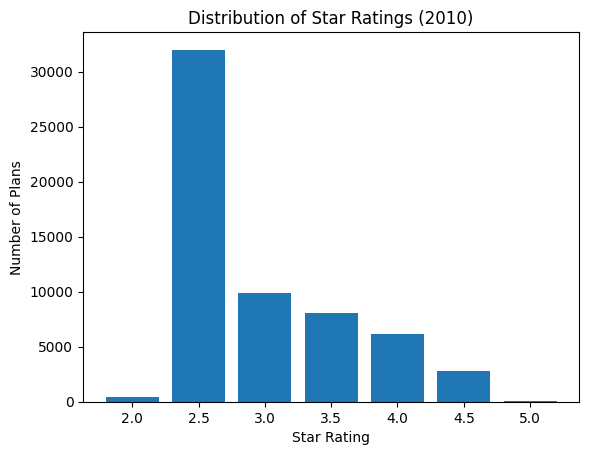

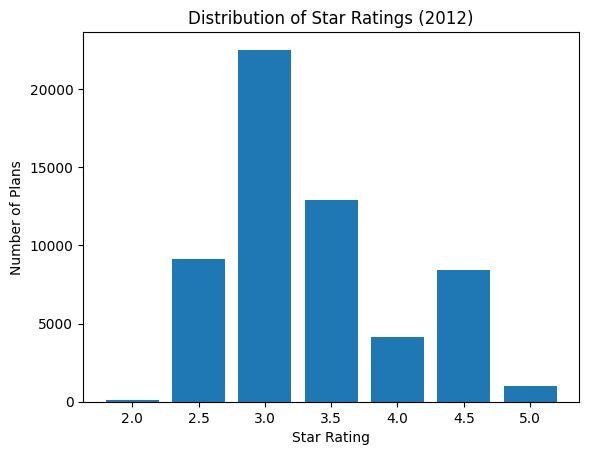

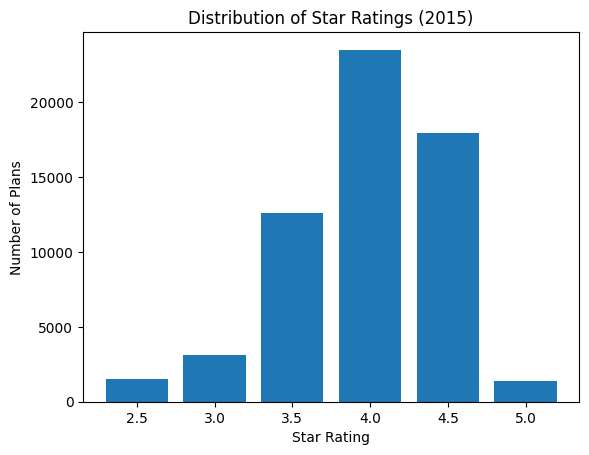

In [6]:
# question 3

# Clean star ratings (numeric)
df = data.copy()
df["star_rating"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Only rated plans and target years
years = [2010, 2012, 2015]
df = df[df["year"].isin(years) & df["star_rating"].notna()]


for y in years:
    sub = df[df["year"] == y]

    counts = (
        sub["star_rating"]
        .value_counts()
        .sort_index()
    )

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of Star Ratings ({y})")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of Plans")
    plt.show()

#### The distribution of Medicare Advantage star ratings shifts noticeably upward between 2010, 2012, and 2015. In 2010, the majority of plans are concentrated around 2.5 to 3 stars, with relatively few plans receiving ratings above 4 stars. This suggests that plan quality, as measured by the star rating system, was generally lower during the early years of the program. By 2012, the distribution begins to move slightly to the right. While 3-star plans remain the most common, there is a visible increase in the number of 3.5- and 4-star plans, indicating some improvement in overall plan quality. By 2015, the distribution shifts substantially toward higher ratings. A large share of plans now receive 4 or 4.5 stars, and the number of low-rated plans (below 3 stars) declines sharply. This suggests that over time plans improved their performance, likely in response to quality incentives and bonus payments tied to higher star ratings. Overall, the graphs indicate a systematic improvement in plan ratings over time, with the distribution moving from lower ratings in 2010 toward higher ratings by 2015.

### Question 4

In [18]:
df = data.copy()

# Dependent variable: market share (plan enrollment / total enrolled in county)
df["market_share"] = np.where(
    pd.to_numeric(df["avg_enrolled"], errors="coerce") > 0,
    pd.to_numeric(df["avg_enrollment"], errors="coerce") / pd.to_numeric(df["avg_enrolled"], errors="coerce"),
    np.nan
)

# Star rating 
df["star"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Star bucket indicators (excluded category: star <= 2.5)
df["star_3"]  = ((df["star"] > 2.5) & (df["star"] < 3.5)).astype(int)   # approx 3.0
df["star_35"] = ((df["star"] >= 3.5) & (df["star"] < 4.0)).astype(int)  # 3.5
df["star_4"]  = ((df["star"] >= 4.0) & (df["star"] < 4.5)).astype(int)  # 4.0
df["star_45p"] = (df["star"] >= 4.5).astype(int)                        # 4.5+

years = range(2010, 2016)
rows = ["Intercept", "Star = 3.0", "Star = 3.5", "Star = 4.0", "Star >= 4.5", "N"]

coef_table = pd.DataFrame(index=rows, columns=[str(y) for y in years], dtype=object)

for y in years:
    sub = df[(df["year"] == y) & df["market_share"].notna()].copy()

    X = sub[["star_3", "star_35", "star_4", "star_45p"]]
    X = sm.add_constant(X)
    yvec = sub["market_share"]

    model = sm.OLS(yvec, X, missing="drop").fit()

    # Fill table with coef 
    coef_table.loc["Intercept", str(y)] = f"{model.params.get('const', np.nan):.4f} ({model.bse.get('const', np.nan):.4f})"
    coef_table.loc["Star = 3.0", str(y)] = f"{model.params.get('star_3', np.nan):.4f} ({model.bse.get('star_3', np.nan):.4f})"
    coef_table.loc["Star = 3.5", str(y)] = f"{model.params.get('star_35', np.nan):.4f} ({model.bse.get('star_35', np.nan):.4f})"
    coef_table.loc["Star = 4.0", str(y)] = f"{model.params.get('star_4', np.nan):.4f} ({model.bse.get('star_4', np.nan):.4f})"
    coef_table.loc["Star >= 4.5", str(y)] = f"{model.params.get('star_45p', np.nan):.4f} ({model.bse.get('star_45p', np.nan):.4f})"
    coef_table.loc["N", str(y)] = int(model.nobs)

coef_table

,2010,2011,2012,2013,2014,2015
Intercept,0.0656 (0.0007),0.0804 (0.0012),0.0661 (0.0017),0.0532 (0.0020),0.0614 (0.0026),0.0540 (0.0021)
Star = 3.0,0.0103 (0.0018),0.0236 (0.0019),0.0417 (0.0021),0.0602 (0.0027),0.0229 (0.0034),0.0374 (0.0035)
Star = 3.5,-0.0017 (0.0019),0.0084 (0.0024),0.0251 (0.0025),0.0339 (0.0023),0.0328 (0.0029),0.0503 (0.0027)
Star = 4.0,-0.0059 (0.0022),-0.0094 (0.0036),-0.0082 (0.0035),0.0189 (0.0032),0.0104 (0.0032),0.0166 (0.0024)
Star >= 4.5,-0.0098 (0.0028),-0.0215 (0.0029),-0.0001 (0.0027),0.0148 (0.0027),0.0072 (0.0031),0.0278 (0.0025)
N,30545,24194,24297,25219,24636,24852


### Question 5

In [20]:
d5 = data.loc[data["year"] == 2010].copy()

# Published star rating
d5["star"] = pd.to_numeric(d5["partcd_score"], errors="coerce")

# Running variable: average of individual metrics
metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]

missing_metrics = [c for c in metric_cols if c not in d5.columns]
if len(missing_metrics) > 0:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d5[c] = pd.to_numeric(d5[c], errors="coerce")

d5["running"] = d5[metric_cols].mean(axis=1, skipna=True)

# Enforce minimum non-missing metrics for a reliable mean
d5.loc[d5[metric_cols].notna().sum(axis=1) < 20, "running"] = np.nan

bins = [2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
labels = ["3.0", "3.5", "4.0", "4.5", "5.0"]

d5["rounded_up_to"] = pd.cut(d5["running"], bins=bins, right=False, labels=labels)

# Numeric version of the bin label (helper for alignment check)
d5["rounded_up_to_num"] = pd.to_numeric(d5["rounded_up_to"].astype(str), errors="coerce")

# Keep only rows where published star and running-implied bucket agree
d5_aligned = d5.loc[
    d5["rounded_up_to"].notna() &
    d5["star"].notna() &
    d5["rounded_up_to_num"].notna() &
    (d5["star"] == d5["rounded_up_to_num"])
].copy()

# Count plans (rows) by rounded-up category USING ONLY aligned rows
rounded_counts = (
    d5_aligned
      .groupby("rounded_up_to")
      .size()
      .reindex(labels, fill_value=0)
      .reset_index(name="n_plans")
      .rename(columns={"rounded_up_to": "rounded_up_star"})
)

rounded_counts

/tmp/ipykernel_768755/2102938154.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rounded_up_to")


,rounded_up_star,n_plans
0,3.0,8862
1,3.5,7718
2,4.0,3601
3,4.5,44
4,5.0,30


### Question 6

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/output/final_star.csv", low_memory=False)

# Focus on 2010
df = df[df["year"] == 2010].copy()

# -----------------------------
# Clean variables
# -----------------------------
df["running"] = pd.to_numeric(df["partc_score"], errors="coerce")
df["enrollment"] = pd.to_numeric(df["avg_enrollment"], errors="coerce")

df = df.dropna(subset=["running", "enrollment"]).copy()

# -----------------------------
# RD function (local linear)
# -----------------------------
def rd_estimate(data, cutoff, bandwidth):
    
    # Restrict to bandwidth window
    d = data.loc[(data["running"] - cutoff).abs() <= bandwidth].copy()
    
    # Treatment indicator
    d["treated"] = (d["running"] >= cutoff).astype(int)
    
    # Center running variable
    d["x"] = d["running"] - cutoff

    # Local linear regression
    X = pd.DataFrame({
        "treated": d["treated"],
        "x": d["x"],
        "treated_x": d["treated"] * d["x"]
    })

    X = sm.add_constant(X)
    y = d["enrollment"]

    model = sm.OLS(y, X).fit(cov_type="HC1")

    return model.params["treated"], model.bse["treated"], len(d)

# -----------------------------
# Estimate at bandwidth = 0.125
# -----------------------------
bandwidth = 0.125

ate_3, se_3, n_3 = rd_estimate(df, cutoff=3.0, bandwidth=bandwidth)
ate_35, se_35, n_35 = rd_estimate(df, cutoff=3.5, bandwidth=bandwidth)

# -----------------------------
# Display results
# -----------------------------
results = pd.DataFrame({
    "Cutoff": ["3.0 stars (vs 2.5)", "3.5 stars (vs 3.0)"],
    "ATE (Enrollment)": [ate_3, ate_35],
    "Std. Error": [se_3, se_35],
    "N within bandwidth": [n_3, n_35]
})

results

,Cutoff,ATE (Enrollment),Std. Error,N within bandwidth
0,3.0 stars (vs 2.5),657.286697,39.478580,3543
1,3.5 stars (vs 3.0),401.952021,20.795577,3185


### Question 7

NameError: name 'data2010' is not defined

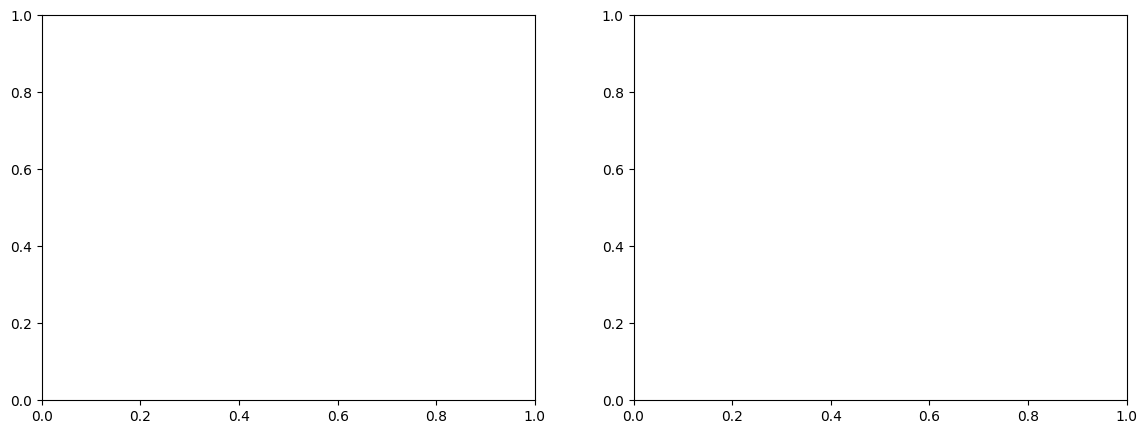

In [21]:
bws = [0.10, 0.12, 0.13, 0.14, 0.15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (star, midpoint, label) in zip(axes, [
    (3.0, 2.75, "3-star vs 2.5-star"),
    (3.5, 3.25, "3.5-star vs 3-star"),
]):
    prev_star = star - 0.5
    candidates = data2010[data2010["Star_Rating"].isin([prev_star, star])].copy()
    candidates["score"]       = candidates["raw_rating"] - midpoint
    candidates["treat"]       = (candidates["score"] >= 0).astype(int)
    candidates["score_treat"] = candidates["score"] * candidates["treat"]
    candidates = candidates.dropna(subset=["avg_enrollment", "score"])

    coefs, ses = [], []
    for bw in bws:
        window = candidates["score"].between(-bw, bw)
        sample = candidates[window]
        if len(sample) < 10:
            coefs.append(np.nan)
            ses.append(np.nan)
            continue
        m = smf.ols("avg_enrollment ~ score + treat + score_treat",
                    data=sample).fit()
        coefs.append(float(m.params["treat"]))
        ses.append(float(m.bse["treat"]))

    coefs = np.array(coefs)
    ses   = np.array(ses)

    ax.plot(bws, coefs, 'o-', linewidth=2, markersize=7)
    ax.fill_between(bws,
                    coefs - 1.96 * ses,
                    coefs + 1.96 * ses,
                    alpha=0.2, label="95% CI")
    ax.axhline(0)
    ax.set_title(f"RD Estimate: {label}")
    ax.set_xlabel("Bandwidth")
    ax.set_ylabel("Effect on Avg. Enrollment")
    ax.legend()

    for bw, coef, n in zip(bws, coefs,
                           [candidates["score"].between(-b, b).sum() for b in bws]):
        ax.annotate(f"n={n}", (bw, coef),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center')

fig.suptitle("Sensitivity of RD Estimates to Bandwidth Choice")
plt.tight_layout()
plt.show()

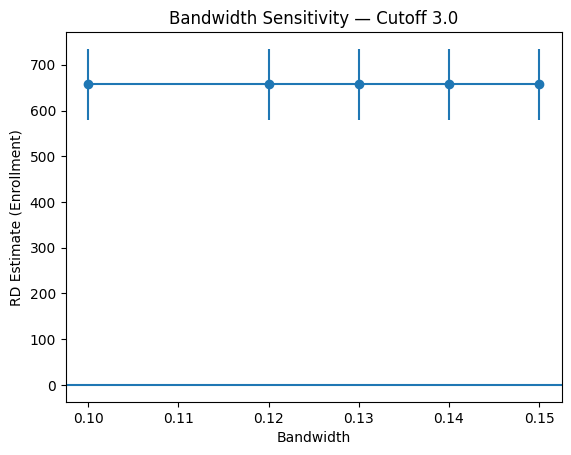

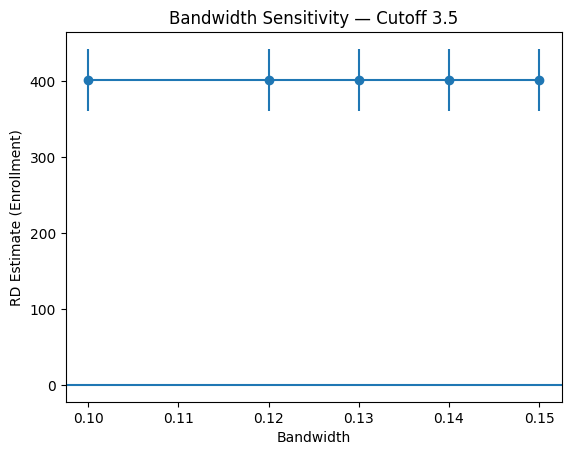

In [11]:
for c in cutoffs:
    sub = res[res["cutoff"] == c].sort_values("bandwidth")
    
    plt.figure()
    plt.errorbar(sub["bandwidth"], sub["ate"],
                 yerr=1.96*sub["se"],
                 marker="o")
    
    plt.axhline(0)
    plt.xlabel("Bandwidth")
    plt.ylabel("RD Estimate (Enrollment)")
    plt.title(f"Bandwidth Sensitivity — Cutoff {c}")
    plt.show()

##### The RD estimates are highly stable across bandwidths ranging from 0.10 to 0.15. At the 3.0-star cutoff, the estimated effect remains around 650 additional enrollees, with confidence intervals that overlap substantially across all bandwidth choices. Similarly, at the 3.5-star cutoff, the estimated effect remains close to 400 additional enrollees and shows minimal variation as the bandwidth changes. There are no sign reversals or large fluctuations in magnitude. Overall, the findings are not sensitive to the choice of bandwidth, suggesting the results are robust.

### Question 8

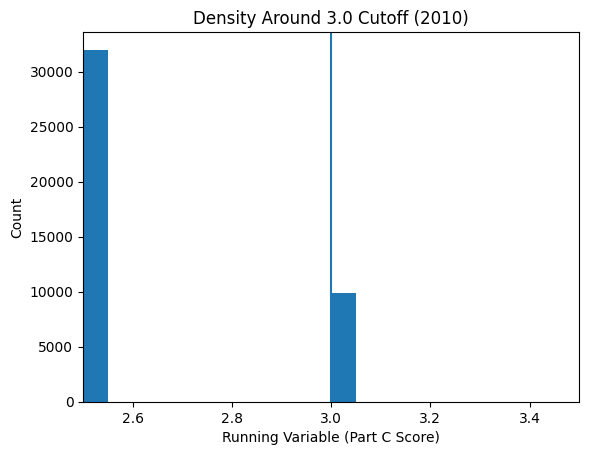

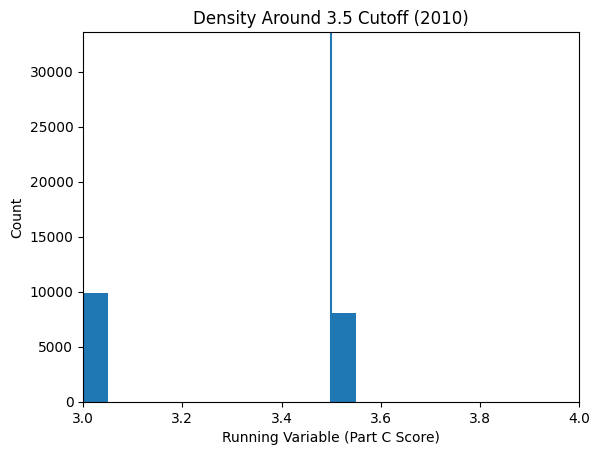

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load 2010 data
df = pd.read_csv("../data/output/final_star.csv", low_memory=False)
df = df[df["year"] == 2010].copy()

df["running"] = pd.to_numeric(df["partc_score"], errors="coerce")
df = df.dropna(subset=["running"])

# ----- Around 3.0 -----
plt.figure()
plt.hist(df["running"], bins=60)
plt.axvline(3.0)
plt.xlim(2.5, 3.5)
plt.title("Density Around 3.0 Cutoff (2010)")
plt.xlabel("Running Variable (Part C Score)")
plt.ylabel("Count")
plt.show()

# ----- Around 3.5 -----
plt.figure()
plt.hist(df["running"], bins=60)
plt.axvline(3.5)
plt.xlim(3.0, 4.0)
plt.title("Density Around 3.5 Cutoff (2010)")
plt.xlabel("Running Variable (Part C Score)")
plt.ylabel("Count")
plt.show()

### Question 9

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load 2010 data
df = pd.read_csv("../data/output/final_star.csv", low_memory=False)
df = df[df["year"] == 2010].copy()

# Running variable
df["running"] = pd.to_numeric(df["partc_score"], errors="coerce")

# Drop missing
df = df.dropna(subset=["running"]).copy()

# -------------------------
# Create HMO indicator
# -------------------------
# If HMO is coded inside plan_type
df["HMO"] = np.where(df["plan_type"].str.contains("HMO", na=False), 1, 0)

# -------------------------
# Create Part D indicator
# -------------------------
df["PartD"] = pd.to_numeric(df["partd"], errors="coerce")

df = df.dropna(subset=["HMO", "PartD"])

In [14]:
def covariate_balance(data, cutoff, bandwidth, variable):

    d = data.loc[(data["running"] - cutoff).abs() <= bandwidth].copy()

    if len(d) == 0:
        print(f"No observations near cutoff {cutoff}")
        return None

    d["treated"] = (d["running"] >= cutoff).astype(int)
    d["x"] = d["running"] - cutoff

    X = pd.DataFrame({
        "treated": d["treated"],
        "x": d["x"],
        "treated_x": d["treated"] * d["x"]
    })

    X = sm.add_constant(X)
    y = d[variable]

    model = sm.OLS(y, X).fit(cov_type="HC1")

    return model.params["treated"], model.pvalues["treated"]

bandwidth = 0.125

print("HMO — 3.0:", covariate_balance(df, 3.0, bandwidth, "HMO"))
print("HMO — 3.5:", covariate_balance(df, 3.5, bandwidth, "HMO"))
print("PartD — 3.0:", covariate_balance(df, 3.0, bandwidth, "PartD"))
print("PartD — 3.5:", covariate_balance(df, 3.5, bandwidth, "PartD"))

No observations near cutoff 3.0
HMO — 3.0: None
No observations near cutoff 3.5
HMO — 3.5: None
No observations near cutoff 3.0
PartD — 3.0: None
No observations near cutoff 3.5
PartD — 3.5: None


### Question 10

In [15]:
#### summary to come in next submission as data needs to be fixed!